# 🏭 The Industry Rigor Toolkit
### Stage 8A: Effect Size, Multiple Testing Correction & Power Analysis  |  ⏱️ ~40-minute session

---

**Recap:** Stages 1–7 gave you the full academic toolkit — every test from t-tests to logistic regression. But there's a gap between "passing a stats course" and "surviving your first real A/B test at work." That gap is exactly what this module fills.

### The three questions this session answers
1. **"My result is significant... but does it actually matter?"** → Effect Size
2. **"I ran 20 tests on this dashboard — can I still trust any of the p-values?"** → Multiple Testing Correction
3. **"How much data do I actually need before I even start collecting it?"** → Power Analysis

These three ideas are what separate an analyst who reports "p < 0.05, ship it!" from one who reports "p < 0.05, effect size is small, and here's the real-world impact we can expect."

### Session map (suggested pacing)

| Time | Topic |
|---|---|
| 0:00 – 0:13 | Effect Size: Cohen's d & Eta-squared |
| 0:13 – 0:24 | Multiple Testing Correction: Bonferroni & Benjamini-Hochberg (FDR) |
| 0:24 – 0:36 | Power Analysis & Sample Size Calculation |
| 0:36 – 0:40 | Recap: putting all three together |

We'll continue using `tips` and `penguins` so you can directly connect today's concepts back to the exact same t-tests and ANOVAs from Stages 3–4.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower

plt.rcParams['figure.figsize'] = (7, 4)
sns.set_style("whitegrid")
np.random.seed(42)

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()

print(tips.shape, penguins.shape)
tips.head()


(244, 7) (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1️⃣ Effect Size — "OK it's significant, but is it BIG?"

### Theory

Here's the uncomfortable truth about p-values: **with a large enough sample, almost ANY tiny difference becomes "statistically significant."** A p-value tells you whether an effect is *detectable* — it says nothing about whether the effect is *large enough to care about*.

**Effect size** fills that gap. It's a standardized measure of "how big is the difference," independent of sample size.

### Cohen's d (for comparing 2 group means — pairs with the t-test)

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{pooled}}$$

It expresses the difference between two means in **standard deviation units**.

| \|d\| | Interpretation |
|---|---|
| 0.2 | Small effect |
| 0.5 | Medium effect |
| 0.8+ | Large effect |

### Scenario
Back in Stage 3, we found smokers and non-smokers had a "significant" (well, actually not-quite-significant) difference in total_bill. Let's actually quantify the effect size, regardless of what the p-value said.


In [2]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

smoker_bills = tips.loc[tips['smoker'] == 'Yes', 'total_bill']
nonsmoker_bills = tips.loc[tips['smoker'] == 'No', 'total_bill']

d = cohens_d(smoker_bills, nonsmoker_bills)
t_stat, p_value = stats.ttest_ind(smoker_bills, nonsmoker_bills)

print(f"t-test: t={t_stat:.3f}, p={p_value:.4f}")
print(f"Cohen's d: {d:.3f}")
print(f"-> This is a {'small' if abs(d)<0.5 else 'medium' if abs(d)<0.8 else 'large'} effect")


t-test: t=1.338, p=0.1820
Cohen's d: 0.176
-> This is a small effect


**The lesson:** even if the p-value had come back significant, d ≈ 0.15-0.2 tells us the practical difference between smoker/non-smoker bills is small — not something you'd necessarily act on in a business decision, even if statistically detectable.

### Eta-squared (η²) — for ANOVA (3+ groups)

$$\eta^2 = \frac{SS_{between}}{SS_{total}}$$

It represents the **proportion of total variance explained by group membership** — conceptually similar to R² in regression.

| η² | Interpretation |
|---|---|
| 0.01 | Small effect |
| 0.06 | Medium effect |
| 0.14+ | Large effect |

### Scenario
Stage 3's ANOVA found species significantly affects penguin body mass. How much of the variance does species actually explain?


In [3]:
def eta_squared(*groups):
    all_data = np.concatenate(groups)
    grand_mean = all_data.mean()
    ss_total = np.sum((all_data - grand_mean) ** 2)
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total

adelie = penguins.loc[penguins['species'] == 'Adelie', 'body_mass_g']
chinstrap = penguins.loc[penguins['species'] == 'Chinstrap', 'body_mass_g']
gentoo = penguins.loc[penguins['species'] == 'Gentoo', 'body_mass_g']

f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)
eta_sq = eta_squared(adelie.values, chinstrap.values, gentoo.values)

print(f"ANOVA: F={f_stat:.3f}, p={p_value:.2e}")
print(f"Eta-squared: {eta_sq:.3f}")
print(f"-> Species membership explains about {eta_sq*100:.1f}% of the variance in body mass -- a LARGE effect")


ANOVA: F=341.895, p=3.74e-81
Eta-squared: 0.674
-> Species membership explains about 67.4% of the variance in body mass -- a LARGE effect


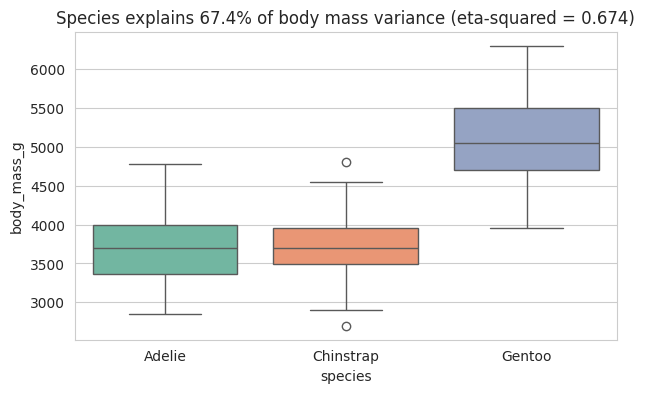

In [4]:
fig, ax = plt.subplots()
sns.boxplot(data=penguins, x='species', y='body_mass_g', hue='species', palette='Set2', ax=ax, legend=False)
ax.set_title(f"Species explains {eta_sq*100:.1f}% of body mass variance (eta-squared = {eta_sq:.3f})")
plt.show()


### 🎯 60-second challenge
Compute Cohen's d for `tip` between Male and Female customers. Is the effect size small, medium, or large?


In [5]:
male_tip = tips.loc[tips['sex'] == 'Male', 'tip']
female_tip = tips.loc[tips['sex'] == 'Female', 'tip']
d_tip = cohens_d(male_tip, female_tip)
print(f"Cohen's d = {d_tip:.3f}")


Cohen's d = 0.185


## 2️⃣ Multiple Testing Correction — "I ran 20 tests. Can I still trust p < 0.05?"

### Theory: the hidden danger of running many tests

Remember: **α = 0.05 means a 5% chance of a false positive on a SINGLE test.** But what if you run 20 tests on the same dataset (very common — dashboards that test every metric, every day-of-week pair, every segment)?

The probability of getting **at least one false positive by pure chance** balloons:

$$P(\text{at least one false positive}) = 1 - (1 - \alpha)^m$$

where *m* = number of tests. Let's see exactly how bad this gets.


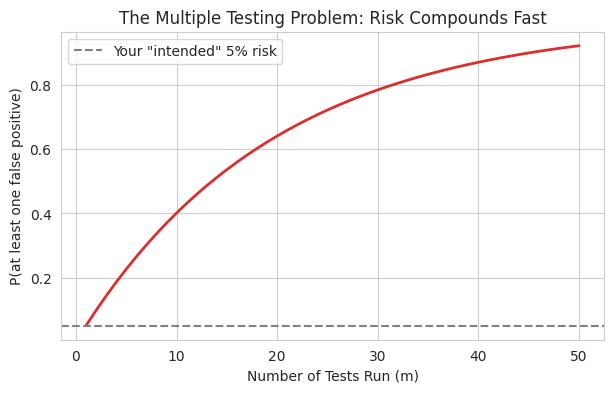

With just 20 tests, P(at least one false positive) = 0.642
With 50 tests, P(at least one false positive) = 0.923


In [6]:
alpha = 0.05
m_tests = np.arange(1, 51)
prob_at_least_one_fp = 1 - (1 - alpha) ** m_tests

fig, ax = plt.subplots()
ax.plot(m_tests, prob_at_least_one_fp, color='#d63031', linewidth=2)
ax.axhline(0.05, color='gray', linestyle='--', label='Your "intended" 5% risk')
ax.set_xlabel("Number of Tests Run (m)")
ax.set_ylabel("P(at least one false positive)")
ax.set_title("The Multiple Testing Problem: Risk Compounds Fast")
ax.legend()
plt.show()

print(f"With just 20 tests, P(at least one false positive) = {1 - (1-alpha)**20:.3f}")
print(f"With 50 tests, P(at least one false positive) = {1 - (1-alpha)**50:.3f}")


**This is the exact trap of dashboards and A/B testing platforms that test many metrics at once** — with 20 tests, you have a ~64% chance of at least one "significant" result appearing purely by chance, even if nothing real is happening anywhere.

### Live demo: false positives from PURE noise
Let's simulate 20 completely random, meaningless comparisons (no real effect anywhere) and see how many come back "significant" by chance alone.


In [7]:
np.random.seed(123)
n_tests = 20
p_values = []

for i in range(n_tests):
    group_a = np.random.normal(50, 10, 30)
    group_b = np.random.normal(50, 10, 30)  # SAME true mean -- no real effect anywhere
    _, p = stats.ttest_ind(group_a, group_b)
    p_values.append(p)

p_values = np.array(p_values)
results_df = pd.DataFrame({'test_number': range(1, n_tests+1), 'p_value': p_values.round(4),
                            'significant_uncorrected': p_values < 0.05})
print(results_df)
print(f"\nFalse 'discoveries' with NO correction: {results_df['significant_uncorrected'].sum()} out of {n_tests}")
print("(Remember: there is NO real effect in ANY of these tests -- every 'significant' result here is a false alarm)")


    test_number  p_value  significant_uncorrected
0             1   0.7579                    False
1             2   0.9013                    False
2             3   0.1600                    False
3             4   0.8454                    False
4             5   0.0667                    False
5             6   0.5618                    False
6             7   0.8640                    False
7             8   0.9011                    False
8             9   0.7634                    False
9            10   0.3088                    False
10           11   0.1358                    False
11           12   0.5354                    False
12           13   0.0267                     True
13           14   0.2715                    False
14           15   0.5085                    False
15           16   0.3332                    False
16           17   0.9390                    False
17           18   0.4750                    False
18           19   0.3724                    False


### The fix: Bonferroni Correction (strict, controls Family-Wise Error Rate)

Simplest approach — just divide your α by the number of tests:

$$\alpha_{adjusted} = \frac{\alpha}{m}$$

Very conservative — guarantees the *overall* chance of ANY false positive stays at 5%, but at the cost of statistical power (real effects can get missed).

### The fix: Benjamini-Hochberg / FDR Correction (less strict, controls False Discovery Rate)

Instead of controlling "any false positive at all," FDR controls the **expected proportion of false positives among your significant results.** It's more lenient and more commonly used in practice (genomics, A/B testing at scale) because Bonferroni is often *too* conservative when you have many tests.


In [8]:
reject_bonf, p_bonf, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
reject_fdr, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

results_df['bonferroni_adjusted_p'] = p_bonf.round(4)
results_df['significant_bonferroni'] = reject_bonf
results_df['fdr_adjusted_p'] = p_fdr.round(4)
results_df['significant_fdr'] = reject_fdr

results_df


,test_number,p_value,significant_uncorrected,bonferroni_adjusted_p,significant_bonferroni,fdr_adjusted_p,significant_fdr
0,1,0.7579,False,1.0000,False,0.9390,False
1,2,0.9013,False,1.0000,False,0.9390,False
2,3,0.1600,False,1.0000,False,0.8001,False
3,4,0.8454,False,1.0000,False,0.9390,False
4,5,0.0667,False,1.0000,False,0.6669,False
5,6,0.5618,False,1.0000,False,0.8643,False
6,7,0.8640,False,1.0000,False,0.9390,False
7,8,0.9011,False,1.0000,False,0.9390,False
8,9,0.7634,False,1.0000,False,0.9390,False
9,10,0.3088,False,1.0000,False,0.8277,False


In [9]:
print(f"Uncorrected 'significant' results:  {results_df['significant_uncorrected'].sum()} / {n_tests}")
print(f"Bonferroni 'significant' results:    {results_df['significant_bonferroni'].sum()} / {n_tests}")
print(f"FDR (Benjamini-Hochberg) results:    {results_df['significant_fdr'].sum()} / {n_tests}")
print("\nBoth corrections correctly wipe out the false alarms, since there was truly no effect anywhere.")


Uncorrected 'significant' results:  1 / 20
Bonferroni 'significant' results:    0 / 20
FDR (Benjamini-Hochberg) results:    0 / 20

Both corrections correctly wipe out the false alarms, since there was truly no effect anywhere.


**When to use which:**
- **Bonferroni:** when a single false positive would be costly (e.g., medical diagnoses, safety-critical decisions) — very strict.
- **Benjamini-Hochberg (FDR):** when you're screening many metrics and can tolerate a small, known proportion of false leads in exchange for catching more real effects (e.g., marketing dashboards, exploratory A/B test screening, genomics).

### 🎯 60-second challenge
Repeat the simulation but inject ONE real effect (make `group_b` in test #1 have a genuinely different mean). Does Bonferroni or FDR correctly still catch it?


In [10]:
np.random.seed(5)
p_values_mixed = []
for i in range(n_tests):
    group_a = np.random.normal(50, 10, 30)
    if i == 0:
        group_b = np.random.normal(58, 10, 30)  # a REAL effect this time
    else:
        group_b = np.random.normal(50, 10, 30)
    _, p = stats.ttest_ind(group_a, group_b)
    p_values_mixed.append(p)

p_values_mixed = np.array(p_values_mixed)
reject_bonf2, _, _, _ = multipletests(p_values_mixed, alpha=0.05, method='bonferroni')
reject_fdr2, _, _, _ = multipletests(p_values_mixed, alpha=0.05, method='fdr_bh')

print(f"Test #1 (the REAL effect) p-value: {p_values_mixed[0]:.5f}")
print(f"Caught by Bonferroni? {reject_bonf2[0]} | Caught by FDR? {reject_fdr2[0]}")


Test #1 (the REAL effect) p-value: 0.00001
Caught by Bonferroni? True | Caught by FDR? True


## 3️⃣ Power Analysis — "How much data do I need BEFORE I collect it?"

### Theory

**Statistical power** (1 − β) is the probability of correctly detecting a real effect, if one truly exists. Power depends on 4 interconnected factors — fix any 3, and you can solve for the 4th:

| Factor | Meaning |
|---|---|
| **Effect size** | How big is the real difference (e.g., Cohen's d) |
| **Sample size (n)** | How many observations per group |
| **Significance level (α)** | Your false-positive tolerance (usually 0.05) |
| **Power (1-β)** | Your desired chance of detecting the effect (commonly 0.80) |

**The most common real-world use:** *"I expect a small-to-medium effect (d=0.3). How many users do I need in my A/B test to have an 80% chance of detecting it?"* — answered BEFORE you run the experiment, not after.

### Practical: solving for sample size


In [11]:
power_analysis = TTestIndPower()

# Scenario: expecting a medium effect (d=0.5), standard alpha=0.05, want 80% power
required_n = power_analysis.solve_power(effect_size=0.5, alpha=0.05, power=0.8, alternative='two-sided')
print(f"Required sample size PER GROUP: {required_n:.1f} (round up to {np.ceil(required_n):.0f})")


Required sample size PER GROUP: 63.8 (round up to 64)


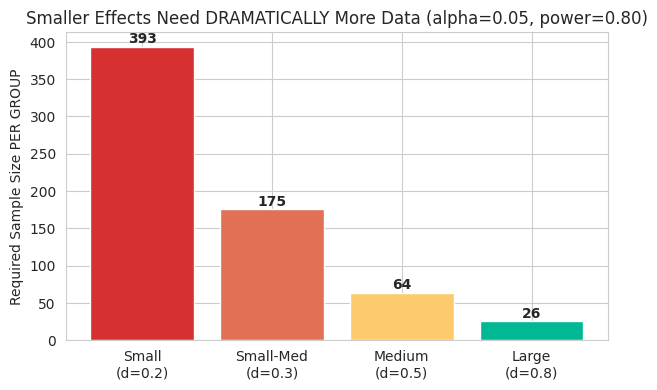

In [12]:
# How does required sample size change with effect size? This is the single most useful chart for planning experiments.
effect_sizes = np.array([0.2, 0.3, 0.5, 0.8])
required_ns = [power_analysis.solve_power(effect_size=e, alpha=0.05, power=0.8) for e in effect_sizes]

fig, ax = plt.subplots()
bars = ax.bar(['Small\n(d=0.2)', 'Small-Med\n(d=0.3)', 'Medium\n(d=0.5)', 'Large\n(d=0.8)'],
              required_ns, color=['#d63031', '#e17055', '#fdcb6e', '#00b894'])
for bar, n in zip(bars, required_ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{n:.0f}', ha='center', fontweight='bold')
ax.set_ylabel("Required Sample Size PER GROUP")
ax.set_title("Smaller Effects Need DRAMATICALLY More Data (alpha=0.05, power=0.80)")
plt.show()


**This is the #1 lesson for anyone running experiments at work:** detecting a small effect (like a 2% conversion lift) requires vastly more users than detecting a large, obvious effect. This is exactly why A/B tests on subtle UI tweaks often need tens of thousands of users, while testing a dramatically different product experience might only need a few hundred.

### Practical: what if I'm stuck with a fixed sample size? Solve for POWER instead.


In [13]:
# Reality check: what if I can only realistically recruit 40 people per group?
achieved_power = power_analysis.solve_power(effect_size=0.5, nobs1=40, alpha=0.05, alternative='two-sided')
print(f"With n=40 per group and a medium effect size (d=0.5), achieved power = {achieved_power:.3f}")
print(f"-> {'Acceptable' if achieved_power >= 0.8 else 'Below the conventional 80% threshold -- risk of missing a real effect'}")


With n=40 per group and a medium effect size (d=0.5), achieved power = 0.598
-> Below the conventional 80% threshold -- risk of missing a real effect


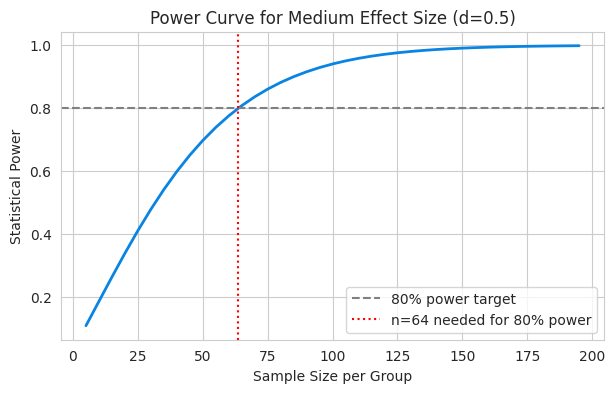

In [14]:
# Power curve: how power grows with sample size, for a medium effect
sample_range = np.arange(5, 200, 5)
power_curve = [power_analysis.solve_power(effect_size=0.5, nobs1=n, alpha=0.05) for n in sample_range]

fig, ax = plt.subplots()
ax.plot(sample_range, power_curve, color='#0984e3', linewidth=2)
ax.axhline(0.8, color='gray', linestyle='--', label='80% power target')
ax.axvline(required_n, color='red', linestyle=':', label=f'n={required_n:.0f} needed for 80% power')
ax.set_xlabel("Sample Size per Group")
ax.set_ylabel("Statistical Power")
ax.set_title("Power Curve for Medium Effect Size (d=0.5)")
ax.legend()
plt.show()


### 🎯 60-second challenge
We measured Cohen's d ≈ 0.15-0.2 earlier for the smoker vs non-smoker total_bill comparison in the real `tips` data. Given that small real-world effect size, how many observations per group would you actually need for 80% power? Compare that to how many smokers/non-smokers are actually in the dataset.


In [15]:
required_n_real = power_analysis.solve_power(effect_size=abs(d), alpha=0.05, power=0.8)
actual_n_smoker = len(smoker_bills)
actual_n_nonsmoker = len(nonsmoker_bills)

print(f"Required n per group for 80% power (d={d:.3f}): {required_n_real:.0f}")
print(f"Actual n -- Smoker: {actual_n_smoker}, Non-Smoker: {actual_n_nonsmoker}")
print(f"\n-> Our dataset is {'UNDERPOWERED' if min(actual_n_smoker, actual_n_nonsmoker) < required_n_real else 'adequately powered'} to reliably detect this small effect!")


Required n per group for 80% power (d=0.176): 505
Actual n -- Smoker: 93, Non-Smoker: 151

-> Our dataset is UNDERPOWERED to reliably detect this small effect!


**This is a genuinely important, humbling result:** it tells us why the smoker/non-smoker t-test in Stage 3 wasn't significant — not necessarily because there's no real difference, but because **the sample size was too small to reliably detect an effect this small.** This is the exact insight power analysis is designed to surface.


## 📋 Cheat Sheet — Stage 8A Recap

| Concept | One-line summary | Tool |
|---|---|---|
| **Cohen's d** | Standardized size of difference between 2 group means | `(mean1-mean2)/pooled_std` |
| **Eta-squared (η²)** | Proportion of variance explained by group membership (3+ groups) | `SS_between / SS_total` |
| **Bonferroni Correction** | Strict: divides α by number of tests; controls ANY false positive | `multipletests(..., method='bonferroni')` |
| **Benjamini-Hochberg (FDR)** | Lenient: controls expected proportion of false positives among "significant" results | `multipletests(..., method='fdr_bh')` |
| **Power Analysis** | Solves for required sample size (or achieved power) given effect size, α, and desired power | `TTestIndPower().solve_power(...)` |

### How these three connect
1. **Effect size** tells you if a result is worth caring about — independent of sample size or p-value.
2. **Power analysis** uses that expected effect size to tell you how much data you need *before* you start.
3. **Multiple testing correction** protects you *after* you've run several tests, so your "significant" findings are still trustworthy.

**Next up:** Stage 8B — putting all of this together in a real **A/B testing framework**, plus **bootstrapping/resampling** for when none of the textbook assumptions hold.
